<div dir="rtl" style="text-align: right; font-family: Tahoma, Vazirmatn, sans-serif; line-height: 1.8;">

<h1>تکلیف : تفسیرپذیری مدل‌های زبانی بزرگ (LLM Interpretability) با BERT</h1>

<h2>مصورسازی بازنمایی‌ها (Representations) قبل و بعد از ریزتنظیم (Fine-tuning)</h2>

<hr>

<h2>مجموعه‌داده (Dataset)</h2>

<p>
در این تکلیف از مجموعه‌داده
<b>SST-2 (Stanford Sentiment Treebank – Binary)</b>
از بنچمارک
<b>GLUE (General Language Understanding Evaluation)</b>
استفاده می‌کنیم.
</p>

<ul>
  <li>حدود <b>67,000</b> جمله برای آموزش (<b>Training</b>)</li>
  <li>حدود <b>870</b> جمله برای اعتبارسنجی (<b>Validation</b>)</li>
  <li>برچسب‌ها (<b>Labels</b>):
    <ul>
      <li><b>0 = منفی (Negative)</b></li>
      <li><b>1 = مثبت (Positive)</b></li>
    </ul>
  </li>
  <li>این مجموعه‌داده مستقیماً از طریق کتابخانه
      <b>🤗 Datasets</b>
      در دسترس است.
  </li>
</ul>

<hr>

<h2>مدل (Model)</h2>

<p>
<b>bert-base-uncased</b>
</p>

<ul>
  <li>دارای <b>12</b> لایه ترنسفورمر (<b>Transformer Layers</b>)</li>
  <li>ابعاد حالت پنهان (<b>Hidden Dimension</b>) برابر با <b>768</b></li>
  <li>حدود <b>110 میلیون</b> پارامتر (<b>Parameters</b>)</li>
</ul>

<hr>

</div>

## 0  Install & Import

In [1]:
# Run once – restart runtime afterwards if prompted
!uv pip install -q transformers datasets umap-learn bertviz matplotlib seaborn scikit-learn torch torchvision

In [2]:
# Imports
from torch.utils.data import DataLoader
import torch
import datasets
from sklearn.decomposition import PCA
import transformers
import pandas as pd
import numpy as np
import seaborn as sns
import umap
import matplotlib.pyplot as plt
import tokenizers
from rich.console import Console
import time
from rich.progress import track
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from rich.table import Table

In [3]:
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
device = torch.device(device)

---
## 1  Load the SST-2 Dataset

In [4]:
# Loads the dataset and prepares the training and validation subsets

dataset = datasets.load_dataset("stanfordnlp/sst2", split=["train", "validation"])

# We work with a small subset so the homework runs fast
N_TRAIN = 2000   # sentences for fine-tuning
N_VAL   = 500    # sentences for validation and visualization

dataset_train = dataset[0].shuffle(seed=42).select(range(N_TRAIN))
dataset_val   = dataset[1].shuffle(seed=42).select(range(N_VAL))


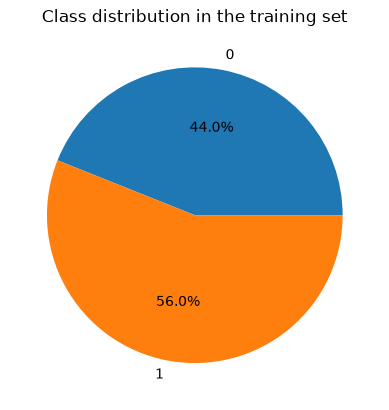

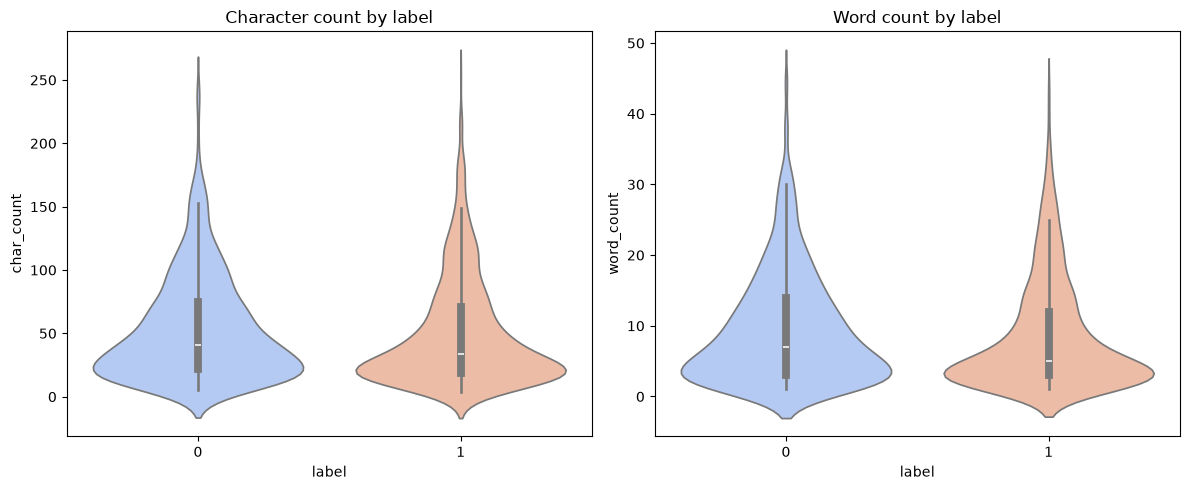

In [5]:
# Class distribution
df = pd.DataFrame(dataset_train)
df.groupby('label').size().plot(kind='pie', autopct='%1.1f%%')
plt.title("Class distribution in the training set")
plt.show()

df["char_count"] = df["sentence"].apply(len)
df["word_count"] = df["sentence"].apply(lambda x: len(x.split()))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Character count by label")
sns.violinplot(
    data=df,
    x="label",
    y="char_count",
    hue="label",
    palette="coolwarm",
    legend=False,
)
plt.subplot(1, 2, 2)
plt.title("Word count by label")
sns.violinplot(
    data=df,
    x="label",
    y="word_count",
    hue="label",
    palette="coolwarm",
    legend=False
)

plt.tight_layout()
plt.show()

---
## 2  Tokenization & DataLoaders

In [6]:
# Tokenization and DataLoader preparation
# tokenizer = tokenizers.ByteLevelBPETokenizer()

# tokenizer.train_from_iterator(dataset_train["sentence"], vocab_size=3000, special_tokens=["<pad>", "<unk>", "<mask>"])
# tokenizer.enable_padding(
#     pad_id=tokenizer.token_to_id("<pad>"),
#     pad_token="<pad>",
# )
tokenizer = transformers.BertTokenizer.from_pretrained("bert-base-uncased")
print("Vocab size", len(tokenizer.get_vocab()))
print("Example:", tokenizer.encode("the quick brown fox jumps over the lazy dog"))  
def get_id_and_mask(batch):
    if hasattr(batch, "input_ids"):
        input_ids = batch.input_ids.to(device)
        attention_mask = batch.attention_mask.to(device)
    else:
        input_ids = [item.ids for item in batch]
        attention_mask = [item.attention_mask for item in batch]
        input_ids = torch.tensor(input_ids).to(device)
        attention_mask = torch.tensor(attention_mask).to(device)
    return input_ids, attention_mask

def collate_fn(batch):
    if hasattr(tokenizer, "encode_batch"):
        X =  tokenizer.encode_batch(
            [item["sentence"] for item in batch], 
            add_special_tokens=True, 
        )
    else:
        X = tokenizer(
            [item["sentence"] for item in batch], 
            padding=True, 
            truncation=True, 
            return_tensors="pt"
        )
    Y = [item["label"] for item in batch]
    Y = np.eye(2)[Y]  
    Y = Y.astype(np.float32)
    Y = torch.tensor(Y).to(device)
    return X, Y



def get_dataloader(ds, shuffle=True):
    return DataLoader(
        ds, 
        batch_size=32, 
        shuffle=shuffle, 
        collate_fn=collate_fn
    )


Vocab size 30522
Example: [101, 1996, 4248, 2829, 4419, 14523, 2058, 1996, 13971, 3899, 102]


---
## 3  Helper: Extract [CLS] Representations

The `[CLS]` token sits at position 0 of every BERT output.
It is designed to aggregate sentence-level information and is what the classification head reads.
We collect it from **every layer** (0 = embedding, 1-12 = transformer layers).

In [7]:
# Helper function to extract [CLS] vectors from each layer of BERT for all examples in the dataloader
def get_cls_vectors(model, data_loader, return_labels=False):
    # make a hook to get each layer's output
    encoder = model.get_encoder()
    outputs = [[] for _ in range(len(encoder.layer))]
    def get_hook(i):
        def inner(module, input, output):
            outputs[i].extend(output[:, 0, :].detach().cpu().numpy())
        return inner
    hooks = []
    for i, layer in enumerate(encoder.layer):
        hooks.append(layer.register_forward_hook(get_hook(i)))
   
    model.eval()
    labels = []
    with torch.no_grad():
        for batch in data_loader:
            input_ids, attention_mask = get_id_and_mask(batch[0])
            model(
                input_ids=input_ids, 
                attention_mask=attention_mask, 
                output_hidden_states=True
            )
            if return_labels:
                labels.extend(batch[1].detach().cpu().numpy())
    for hook in hooks:
        hook.remove()
    outputs = np.array(outputs)  
    if return_labels:
        labels = np.array(labels)
        labels = labels.argmax(axis=1)  
        return outputs, labels
    return outputs

---
## 4  Part A — Pretrained BERT (Before Fine-tuning)
### 4.1  Load pretrained BERT & extract representations

In [8]:
# Load the pretrained BERT model and extract the [CLS] vectors for the validation set
transformers.logging.set_verbosity_error()  
model_pretrained = transformers.BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels = 2).to(device)
dataloader = get_dataloader(dataset_val, shuffle=False)
print("Getting cls")
t = time.time()
pretrained_cls_vectors, pretrained_shuffled_labels = get_cls_vectors(model_pretrained, dataloader, return_labels=True)
print("Took", time.time() - t, "seconds")
print(f"{pretrained_cls_vectors.shape = }")
print(f"{pretrained_shuffled_labels.shape = }")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Getting cls
Took 2.3932862281799316 seconds
pretrained_cls_vectors.shape = (12, 500, 768)
pretrained_shuffled_labels.shape = (500,)


### 4.2  PCA Visualisation — all 12 transformer layers

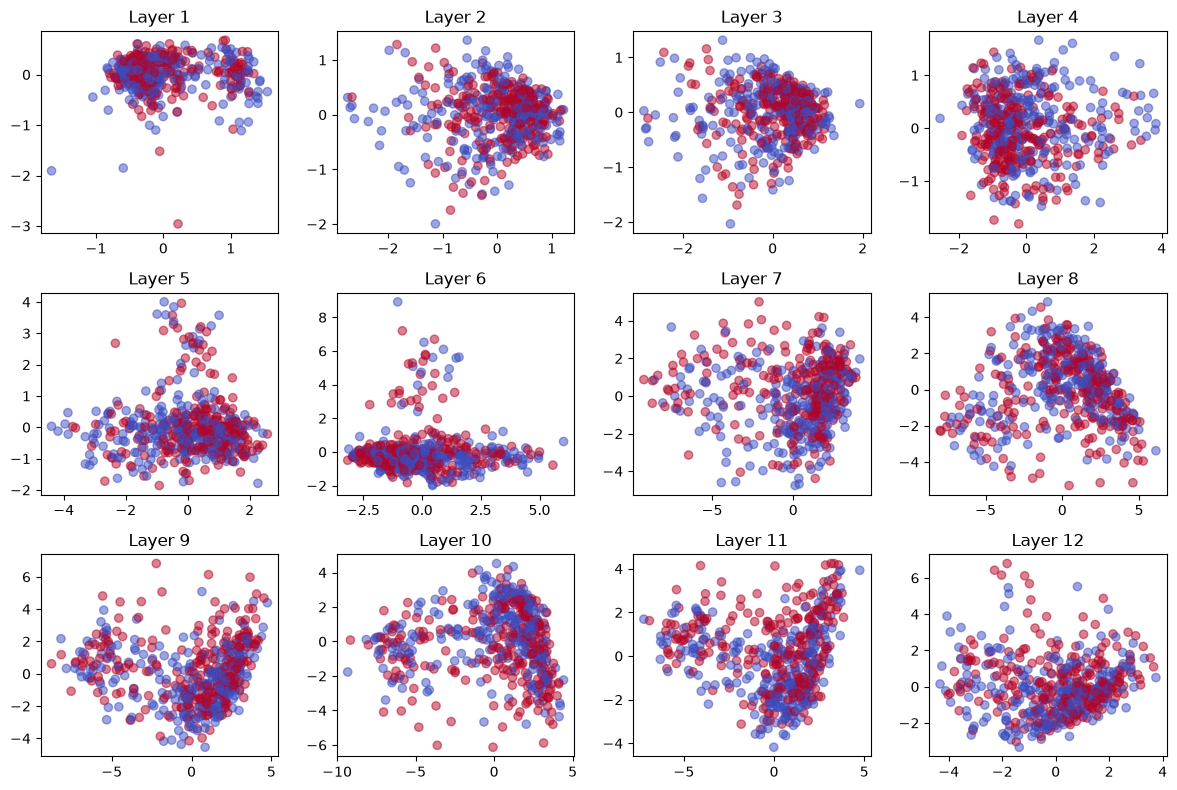

In [9]:
# Visualize the PCA projections of the [CLS] vectors for selected layers in a grid format
def plot_cls(cls_vectors, labels ):
    # cls (n * 768)
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(cls_vectors)
    plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='coolwarm', alpha=0.5)
plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plot_cls(pretrained_cls_vectors[i], pretrained_shuffled_labels)
    plt.title(f"Layer {i + 1}")
plt.tight_layout()
plt.show()

### 4.3  UMAP — deep layers only

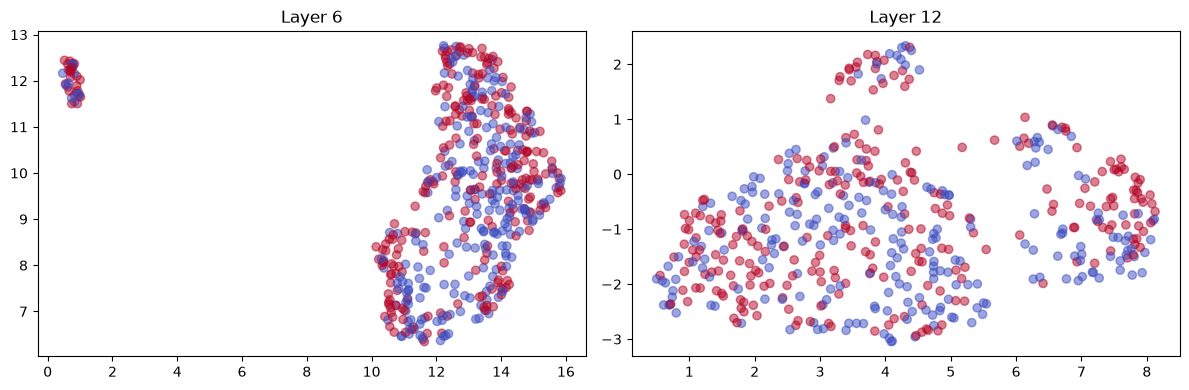

In [10]:
# Visualize the UMAP projections of the [CLS] vectors for selected layers (6, 12) in a grid format
def plot_cls_umap(cls_vectors, labels ):
    # cls (n * 768)
    u= umap.UMAP(n_components=2)
    reduced = u.fit_transform(cls_vectors)
    plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='coolwarm', alpha=0.5)
plt.figure(figsize=(12, 4))
for i in range(2):
    layer_idx = 6 * (i + 1) - 1
    plt.subplot(1, 2, i + 1)
    plot_cls_umap(pretrained_cls_vectors[layer_idx], pretrained_shuffled_labels)
    plt.title(f"Layer {layer_idx + 1}")
plt.tight_layout()
plt.show()

### 4.4  Layer-wise linear separability (Logistic Probe)
Train a simple logistic regression on each layer's [CLS] vectors.
If accuracy is high, the layer already encodes sentiment linearly.

In [31]:
# Probing classifier: train a logistic regression classifier on the [CLS] vectors from each layer and evaluate using 5-fold cross-validation

def probe_logistic_regression(cls_vectors, labels, print_table=True):
    scores = []

    table = Table(title="Probing Classifier Results")
    table.add_column("Layer", justify="right", style="cyan", no_wrap=True)
    table.add_column("Mean Accuracy", justify="right", style="green")
    table.add_column("Std Dev", justify="right", style="red")
    for i in range(12):
        X = cls_vectors[i]
        y = labels

        clf = LogisticRegression(
            max_iter=1000,
            random_state=42,
        )

        cv_scores = cross_val_score(
            clf,
            X,
            y,
            cv=5,
            scoring="accuracy",
        )

        scores.append(cv_scores.mean())
        table.add_row(
            str(i + 1),
            f"{cv_scores.mean():.4f}",
            f"{cv_scores.std():.4f}",
        )
    if print_table:
        console = Console()
        console.print(table)
    return scores
pretrained_scores = probe_logistic_regression(pretrained_cls_vectors, pretrained_shuffled_labels)

    Probing Classifier Results     
┏━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer ┃ Mean Accuracy ┃ Std Dev ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│     1 │        0.6620 │  0.0574 │
│     2 │        0.7060 │  0.0265 │
│     3 │        0.6920 │  0.0256 │
│     4 │        0.7480 │  0.0075 │
│     5 │        0.7440 │  0.0150 │
│     6 │        0.7380 │  0.0331 │
│     7 │        0.7540 │  0.0427 │
│     8 │        0.7680 │  0.0412 │
│     9 │        0.7780 │  0.0366 │
│    10 │        0.7720 │  0.0387 │
│    11 │        0.8020 │  0.0271 │
│    12 │        0.8440 │  0.0361 │
└───────┴───────────────┴─────────┘

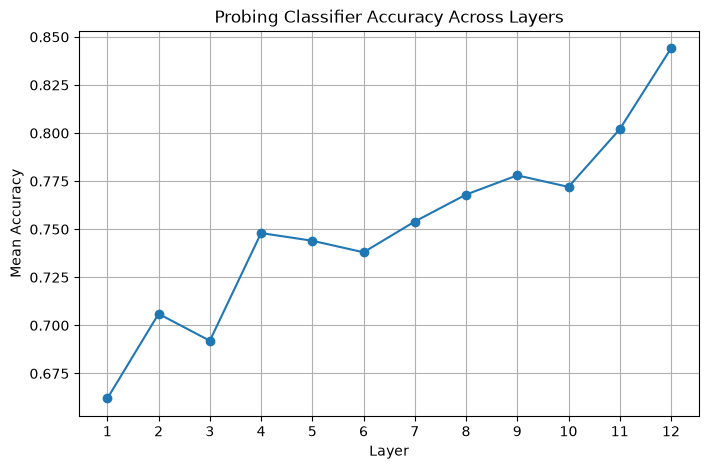

In [15]:
# Visualize the probe scores across layers
plt.figure(figsize=(8, 5))
plt.plot(range(1, 13), pretrained_scores, marker='o')
plt.title("Probing Classifier Accuracy Across Layers")
plt.xlabel("Layer")
plt.ylabel("Mean Accuracy")
plt.xticks(range(1, 13))
plt.grid()
plt.show()

> **💬 Question 1 (written answer):**  
> Looking at the probe accuracy plot, which layers encode sentiment information most strongly in the *pretrained* model? Is sentiment already linearly separable before any fine-tuning?

*last layer has the best accuracy, so it means that it has the most sentiment information. but looking at PCA and UMAP plots, we can see that data is not linear seperable. 
it means that at higher dimension, there is some line that can seperate data and so we can infer that sentiment information is present. but they are not so powerful because when we reduce dimension, these sentiment information are lost.*

---
## 5  Part B — Fine-tuning BERT on SST-2
### 5.1  Initialise model

In [16]:
# Fine-tuning the BERT model for classification
transformers.logging.set_verbosity_error()  
model_finetune = transformers.BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels = 2).to(device)
# model_finetune = transformers.BertModel.from_pretrained("bert-base-uncased").to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

### 5.2  Training loop

In [ ]:
# Set up the optimizer and learning rate scheduler and train the model for a few epochs (3), recording the training loss
optimizer = torch.optim.AdamW(model_finetune.parameters(), lr=5e-5)
model_finetune.train()
dataloader_train = get_dataloader(dataset_train)
dataloader_val = get_dataloader(dataset_val, shuffle=False)
batch_loss = []
for epoch in range(3):
    total_loss = 0
    for batch in track(dataloader_train):
        input_ids, attention_mask = get_id_and_mask(batch[0])
        finetuned_shuffled_labels = batch[1]

        optimizer.zero_grad()
        outputs = model_finetune(
            input_ids=input_ids, 
            attention_mask=attention_mask, 
            output_hidden_states=True
        )
        # cls_output = outputs.last_hidden_state[:, 0, :]
        loss_fn = torch.nn.CrossEntropyLoss()
        loss = loss_fn(outputs.logits, finetuned_shuffled_labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        batch_loss.append(loss.item())

    avg_loss = total_loss / len(dataloader_train)
    print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}")

Output()

Output()

Epoch 1, Loss: 0.4438


Output()

Epoch 2, Loss: 0.1884


Epoch 3, Loss: 0.0809


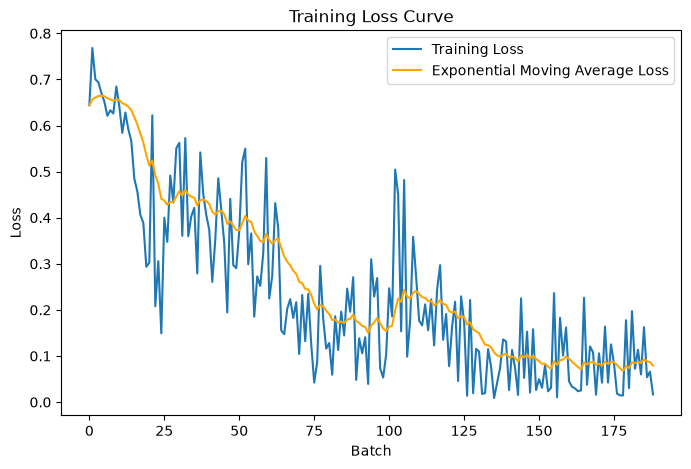

In [18]:
# visualize the training loss curve
plt.figure(figsize=(8, 5))
plt.plot(batch_loss, label="Training Loss")
average_loss = [batch_loss[0]]
alpha = 0.1
for i in range(1, len(batch_loss)):
    average_loss.append(alpha * batch_loss[i] + (1 - alpha) * average_loss[-1])
plt.plot(average_loss, label="Exponential Moving Average Loss", color='orange')
plt.title("Training Loss Curve")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.legend()
plt.show()

---
## 6  Part C — Fine-tuned BERT: Extract & Visualise Representations

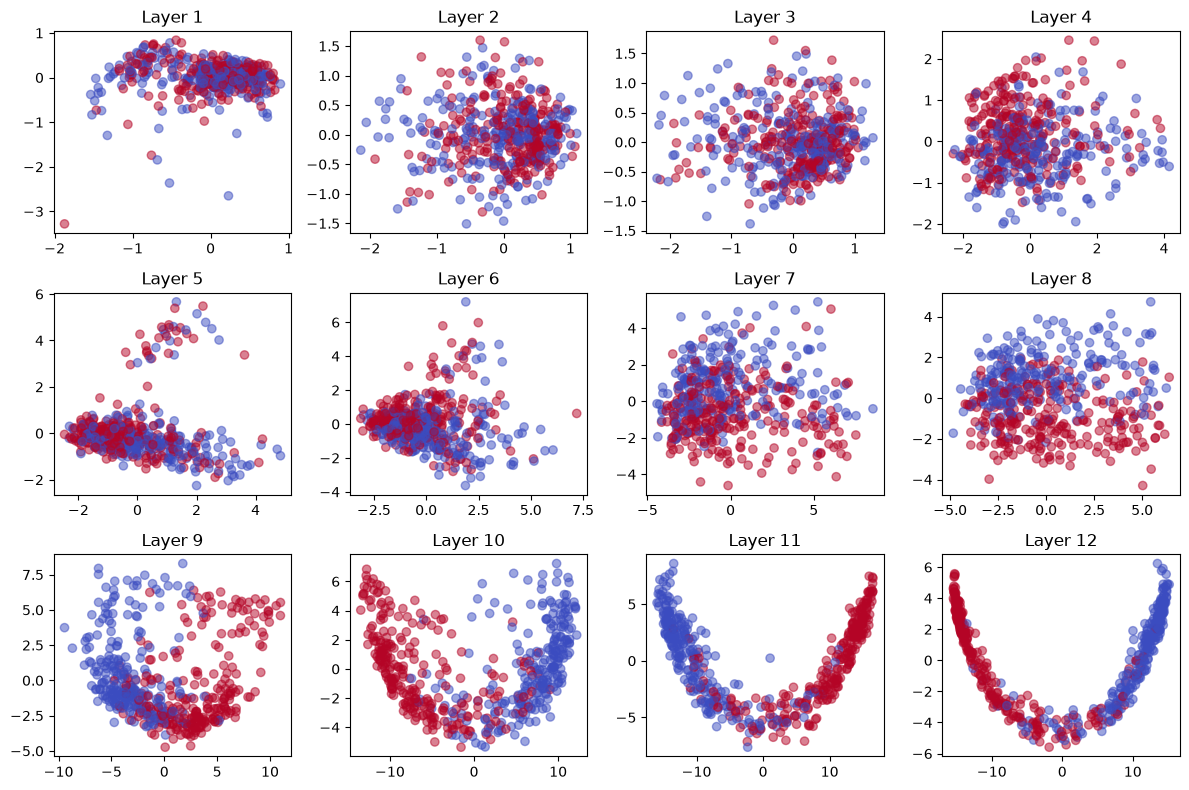

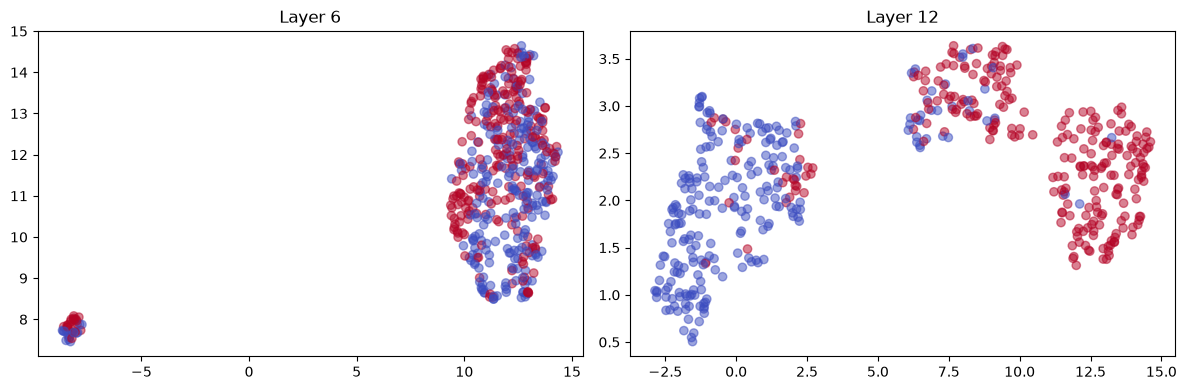

In [22]:
# Extract the [CLS] vectors from the fine-tuned model for the validation set and visualize the PCA and UMAP projections again to see how they changed after fine-tuning
finetuned_cls_vectors, finetuned_shuffled_labels = get_cls_vectors(model_finetune, dataloader_val, return_labels=True)
plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plot_cls(finetuned_cls_vectors[i], finetuned_shuffled_labels)
    plt.title(f"Layer {i + 1}")
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 4))
for i in range(2):
    layer_idx = 6 * (i + 1) - 1
    plt.subplot(1, 2, i + 1)
    plot_cls_umap(finetuned_cls_vectors[layer_idx], finetuned_shuffled_labels)
    plt.title(f"Layer {layer_idx + 1}")
plt.tight_layout()
plt.show()

---
## 7  Part D — Direct Comparison: Before vs After

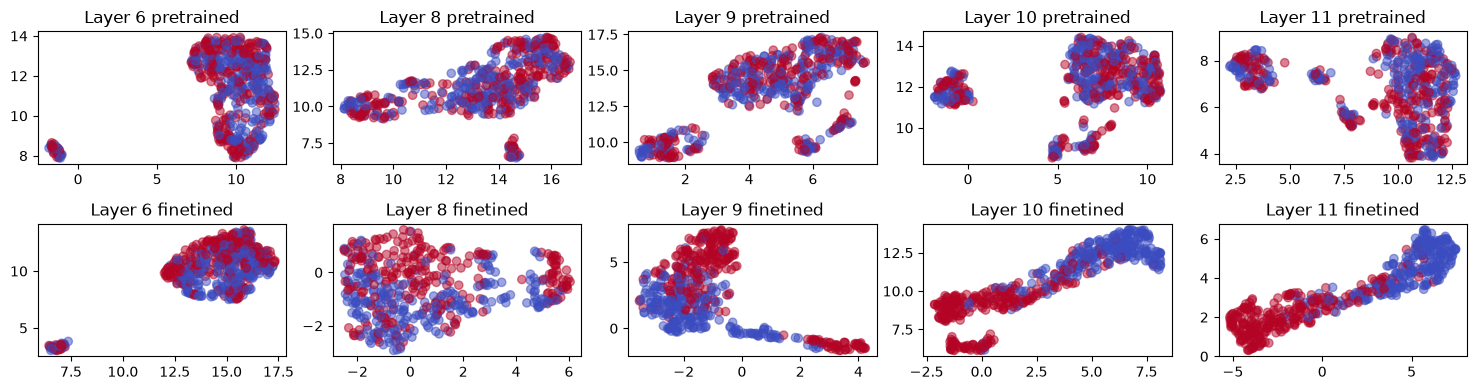

In [39]:
# Helper function to plot PCA or UMAP projections side-by-side for pretrained vs fine-tuned representations
layers = (5, 7, 8, 9, 10)
plt.figure(figsize=(3 * len(layers), 4))

for i, layer_idx in enumerate(layers):
    plt.subplot(2, len(layers), i + 1)
    plot_cls_umap(pretrained_cls_vectors[layer_idx], pretrained_shuffled_labels)
    plt.title(f"Layer {layer_idx + 1} pretrained")

    plt.subplot(2, len(layers), i + 1 + len(layers))
    plot_cls_umap(finetuned_cls_vectors[layer_idx], finetuned_shuffled_labels)
    plt.title(f"Layer {layer_idx + 1} finetined")

plt.tight_layout()
plt.show()

### 7.1  Probe accuracy comparison

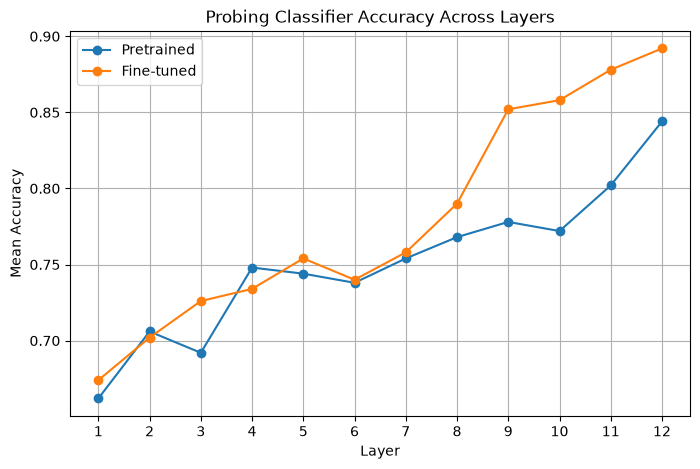

In [34]:
# visualize probe scores before and after fine-tuning
finetuned_scores = probe_logistic_regression(finetuned_cls_vectors, finetuned_shuffled_labels, print_table=False)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 13), pretrained_scores, marker='o', label="Pretrained")
plt.plot(range(1, 13), finetuned_scores, marker='o', label="Fine-tuned")
plt.title("Probing Classifier Accuracy Across Layers")
plt.xlabel("Layer")
plt.ylabel("Mean Accuracy")
plt.xticks(range(1, 13))
plt.legend()
plt.grid()

> **💬 Question 2 (written answer):**  
> Compare the probe accuracy curves before and after fine-tuning.  
> a) Which layers changed the most?  
> b) Why do you think those specific layers changed while others did not?  

*a) up to layer 7, we can see that accuracy is almost same as pretrained. but after that, the finetuning starts to pay off and the accuracy is higher than pretrained. so layer 8, 9, 10, 11 and 12 changed most*

*b) well, the first layers are getting the basic information from the scentance so we can't expect them to capture deep meanings from the scentances. but as we go deeper, the model become more adept at finding deeper meanings so we see that in deep layers, the sentiment information become stronger and more seperable*

### 7.2  Inter-layer cosine similarity heatmap
How similar are representations across layers? Does fine-tuning change layer similarity?

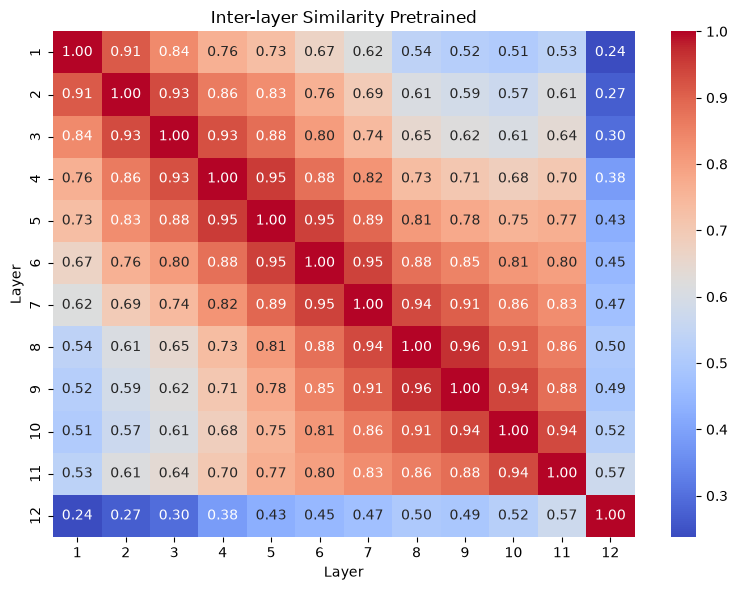

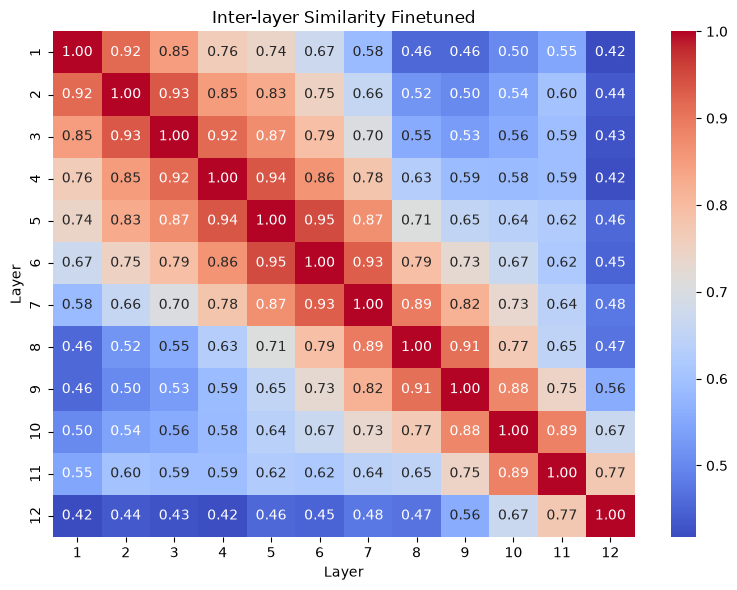

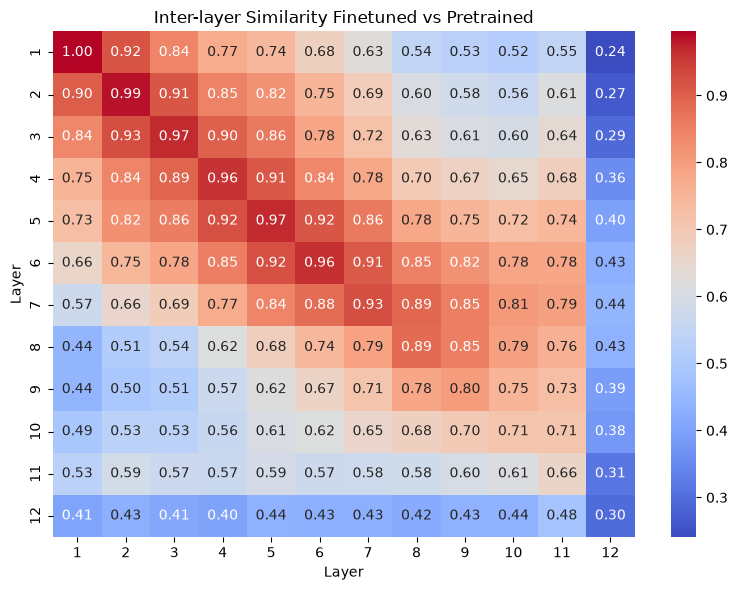

In [ ]:
# Inter-layer similarity analysis: compute the average cosine similarity between the mean [CLS] vectors of every layer pair, before and after fine-tuning, and visualize as heatmaps

# since i couldn't find question wants to compare the cls between layers of the same model or between the two models (i think between models is more useful but the question text say multiple heatmaps), so i did both. 
assert all(pretrained_shuffled_labels == finetuned_shuffled_labels)
def compute_cosine_similarity_matrix(cls_vectors1, cls_vectors2 = None):
    if cls_vectors2 is None:
        cls_vectors2 = cls_vectors1

    num_layers = cls_vectors1.shape[0]
    ans = np.zeros((num_layers, num_layers))
    for i in range(num_layers):
        for j in range(num_layers):
            mean_i = np.mean(cls_vectors1[i], axis=0)
            mean_j = np.mean(cls_vectors2[j], axis=0)
            ans[i, j] = np.dot(mean_i, mean_j) / (np.linalg.norm(mean_i) * np.linalg.norm(mean_j))
    return ans
def plot_heatmap(similarity_matrix, title):
    plt.figure(figsize=(8, 6))
    ticks = range(1, similarity_matrix.shape[0] + 1)
    sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=ticks, yticklabels=ticks)
    plt.title(title)
    plt.xlabel("Layer")
    plt.ylabel("Layer")
    plt.tight_layout()
    plt.show()

pretrained_similarity_matrix = compute_cosine_similarity_matrix(pretrained_cls_vectors)
plot_heatmap(pretrained_similarity_matrix, "Inter-layer Similarity Pretrained")
finetuned_similarity_matrix = compute_cosine_similarity_matrix(finetuned_cls_vectors)
plot_heatmap(finetuned_similarity_matrix, "Inter-layer Similarity Finetuned")
finetuned_pretrained_similarity_matrix = compute_cosine_similarity_matrix(finetuned_cls_vectors, pretrained_cls_vectors)
plot_heatmap(finetuned_pretrained_similarity_matrix, "Inter-layer Similarity Finetuned vs Pretrained")

> **💬 Question 3 (written answer):**  
> Looking at the inter-layer similarity heatmaps, describe how the layer structure changes after fine-tuning.  
> Are the deep layers more or less similar to each other compared to the pretrained model?

*we can see that in pretrained model, the layer are more similar. but in finetuned model, layers are more different. (when tracing the main diagonal, in pretrained, the neighbour of diagonal still has high score but in finetune the similarity drop faster). it is as if by finetuning, we make the weights sharper (same effect we see on overfitting because in a way we overfit to a specific domain*

*no. compared to pretrained the deep layers are more different in finetune model. except for the last layer which is more similar to layer 11 in finetuned model than the pretrained model*

*(extra) also by plotting pretrain and finetune similarity, we can see the main changes occur at deep layers. and it is predictable because the accuracy began to rise in the same deep layers.*

---
## 8  Final Evaluation

Output()

accuracy: 0.8800


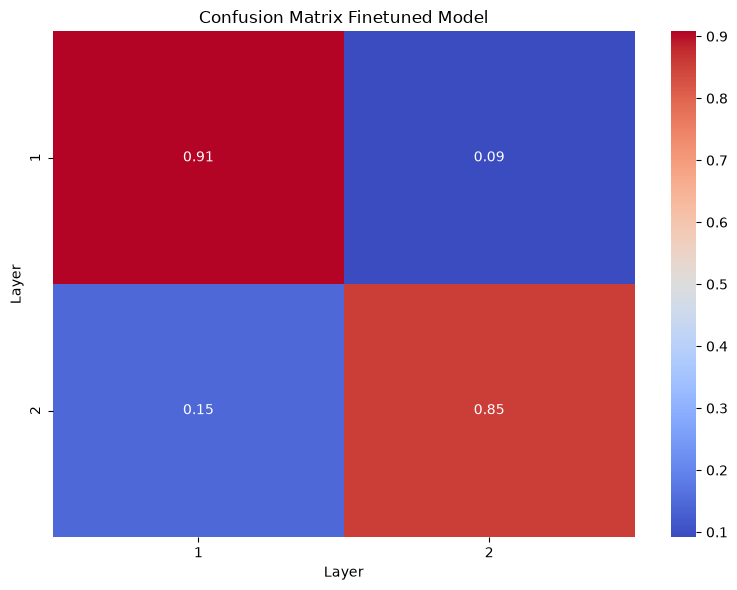

In [61]:
# Final evaluation of the fine-tuned model on the validation set
model_finetune.eval()
correct = 0
confusion_matrix = np.zeros((2, 2), dtype=int)

with torch.no_grad():
    for batch in track(dataloader_val):
        input_ids, attention_mask = get_id_and_mask(batch[0])
        outputs = model_finetune(
            input_ids=input_ids, 
            attention_mask=attention_mask, 
            output_hidden_states=True
        )
        preds = torch.argmax(outputs.logits, dim=1)
        actuals = torch.argmax(batch[1], dim=1)
        correct += (preds.cpu().numpy() == actuals.cpu().numpy()).sum()
        # Update confusion matrix
        for i in range(len(preds)):
            confusion_matrix[actuals[i], preds[i]] += 1
accuracy = correct / len(dataset_val)
print(f"accuracy: {accuracy:.4f}")
confusion_matrix = confusion_matrix / confusion_matrix.sum(axis=1, keepdims=True)  # Normalize
plot_heatmap(confusion_matrix, "Confusion Matrix Finetuned Model")


---
## 9  Summary & Reflection

> **💬 Question 4 (written answer — ~200 words):**  
> Summarise what you observed across all four parts.  
> - What did the PCA / UMAP visualisations show about how representations change?  
> - What does the probe accuracy tell us about where sentiment is encoded?  
> - What is one limitation of the visualisation approach we used (e.g. PCA projection)?  

*Write your answer here.*

*PCA/UMAP visalization showed that in pretrained model, the sentiment information is not that strong but in finetune model, the sentiment information is so strong that only by using 2 of the principal components, we can seperate data by a line.*

*we see that in both models, the probe accuracy is somewhat high which means both model contain the info. but in finetuned model, the sentiment information is more evident. 
we can also see the deeper we go, the model become more adept at understanding the sentiment meanings. *

*we saw that even thoght the pretrained model had good accuracy, in PCA/UMAP data was not seperable at all. that's because the sentiment information was not strong enought to maximize the spread of data. it was a minor feature. perhaps by using some supervised method (for example Fischer Analysis) we can overcome this issue becuase it address the discriminant objective we have.*